In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from scipy.stats import linregress

In [ ]:
BASE = Path("../data")

nav = pd.read_csv(
BASE/"processed"/"clean_nav_history.csv"
)

perf = pd.read_csv(
BASE/"processed"/"clean_scheme_performance.csv"
)

bench = pd.read_csv(
BASE/"raw"/"10_benchmark_indices.csv"
)

nav["date"] = pd.to_datetime(nav["date"]
)

print(nav.shape)

(46000, 3)


Text(0.5, 1.0, 'Daily Return Distribution')

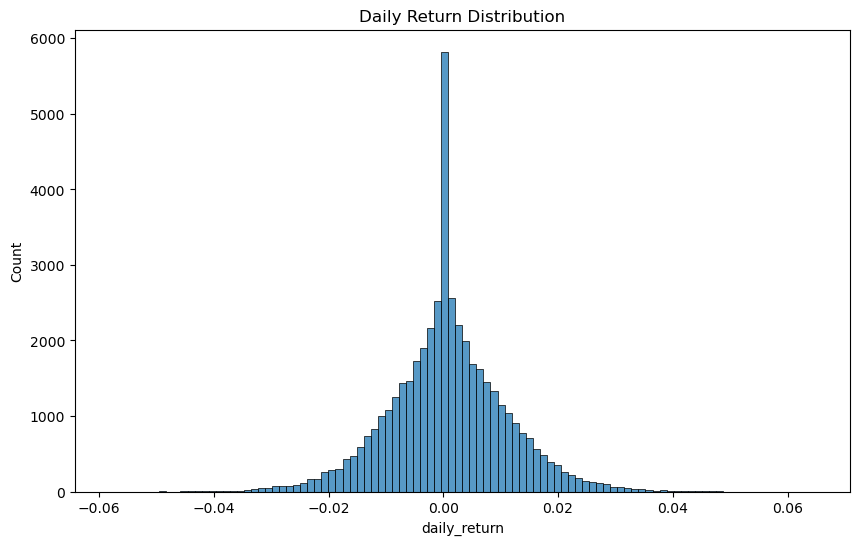

In [ ]:
nav = nav.sort_values(
["amfi_code","date"]
)

nav["daily_return"] = (

nav.groupby("amfi_code")["nav"].pct_change()

)

plt.figure(
figsize=(10,6)
)

sns.histplot(
nav["daily_return"].dropna(),bins=100

)

plt.title("Daily Return Distribution")


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from scipy.stats import linregress

BASE = Path("../data")

nav = pd.read_csv(
BASE/"processed"/"clean_nav_history.csv"
)

nav["date"] = pd.to_datetime(nav["date"])


print(nav.shape)

nav.head()

(46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [ ]:
nav = nav.sort_values(
["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"].pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [ ]:
cagr = (
nav.groupby("amfi_code")["nav"].agg(["first","last"])
)

for yrs in [1,3,5]:
        cagr[f"CAGR_{yrs}"]=((cagr["last"] / cagr["first"])**(1/yrs)-1)*100

print(cagr.head())

              first      last      CAGR_1     CAGR_3     CAGR_5
amfi_code                                                      
100016     520.4608  583.6113   12.133575   3.891151   2.316843
100025      26.3169   31.8843   21.155227   6.605772   3.912653
100033     107.3758  342.0072  218.514228  47.132838  26.074068
101206     305.0996  773.2939  153.456216  36.343461  20.442730
101207      38.5736   53.9836   39.949603  11.855469   6.953336


In [ ]:
rf = 0.065

mean_return = (
    nav.groupby("amfi_code")["daily_return"].mean()
)

std_return = (
    nav.groupby("amfi_code")["daily_return"].std()
)

sharpe = (
    (mean_return - (rf/252)) / std_return) * np.sqrt(252)

sharpe = sharpe.sort_values(
ascending=False
)

print(sharpe.head())

amfi_code
148567    1.448291
120843    1.306744
148569    1.234930
119551    1.208267
120505    1.180101
Name: daily_return, dtype: float64


In [ ]:
downside = (

nav[nav["daily_return"]<0].groupby("amfi_code")["daily_return"].std()

)

sortino = (
    (mean_return - (rf/252)) / downside

)

print(sortino.head())

amfi_code
100016   -0.022114
100025   -0.059329
100033    0.115225
101206    0.113362
101207    0.017427
Name: daily_return, dtype: float64


In [ ]:
metrics = pd.DataFrame({
"CAGR_3":cagr["CAGR_3"],"Sharpe":sharpe,"Sortino":sortino

})

metrics.to_csv(BASE/"processed"/"performance_metrics.csv",
index=True

)

print("saved")

saved


In [14]:
bench = pd.read_csv(
BASE/"raw"/"10_benchmark_indices.csv"
)

print(
bench.columns
)

bench.head()

Index(['date', 'index_name', 'close_value'], dtype='object')


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [15]:
print(
bench.columns
)

bench.head()

Index(['date', 'index_name', 'close_value'], dtype='object')


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [17]:
print(
bench.columns
)

bench.head()

Index(['date', 'index_name', 'close_value'], dtype='object')


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [5]:
import pandas as pd
import numpy as np

from pathlib import Path
from scipy.stats import linregress

BASE = Path("../data")

nav = pd.read_csv(
BASE/"processed"/"clean_nav_history.csv"
)

nav["date"] = pd.to_datetime(
nav["date"]
)

nav = nav.sort_values(
["amfi_code","date"]
)

nav["daily_return"] = (
nav.groupby(
"amfi_code"
)["nav"]
.pct_change()
)

print(nav.shape)

(46000, 4)


In [6]:
bench = pd.read_csv(
BASE/"raw"/"10_benchmark_indices.csv"
)

print(
bench.columns
)

Index(['date', 'index_name', 'close_value'], dtype='object')


In [8]:
bench["date"] = pd.to_datetime(
bench["date"]
)

bench["benchmark_return"] = (
bench["close_value"]
.pct_change()
)

bench.head()

print(
bench.head()
)

        date index_name  close_value  benchmark_return
0 2022-01-03    NIFTY50     17492.79               NaN
1 2022-01-04    NIFTY50     17689.64          0.011253
2 2022-01-05    NIFTY50     17835.05          0.008220
3 2022-01-06    NIFTY50     17878.51          0.002437
4 2022-01-07    NIFTY50     17759.15         -0.006676


In [ ]:
from scipy.stats import linregress

result=[]

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"]==code][["date","daily_return"]]

    merged = fund.merge(

        bench[["date","benchmark_return"],
              on="date"]

    )

    merged = merged.dropna()

    if len(merged)>30:
        slope, intercept, _, _, _ = linregress(
        merged["benchmark_return"],merged["daily_return"]
            )

        result.append([
            code,intercept*252,slope
        ])

alpha_beta = pd.DataFrame(
result,columns=["amfi_code","alpha","beta"]
)

print(alpha_beta.head())

   amfi_code     alpha      beta
0     100016  0.035008  0.004843
1     100025  0.043330 -0.003422
2     100033  0.268752  0.024097
3     101206  0.214656 -0.000067
4     101207  0.110250 -0.023588


In [ ]:
alpha_beta.to_csv(

BASE/"processed"/"alpha_beta.csv",

index=False

)

print("saved")

saved


In [ ]:
nav["running_max"]=(

nav.groupby("amfi_code")["nav"].cummax()

)
nav["drawdown"]=(nav["nav"] / nav["running_max"])-1 
max_dd=(nav.groupby("amfi_code")["drawdown"].min()

)

print(
max_dd.head()
)

amfi_code
100016   -0.247344
100025   -0.043083
100033   -0.162172
101206   -0.112916
101207   -0.354469
Name: drawdown, dtype: float64


In [12]:
max_dd.to_csv(

BASE/
"processed"/
"max_drawdown.csv"

)

print("saved")

saved


In [ ]:
perf = pd.read_csv(
BASE/"processed"/"clean_scheme_performance.csv"
)

print(perf.columns)
perf.head()

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'expense_flag'],
      dtype='object')


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,expense_flag
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,True
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,True
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,True


In [ ]:
perf = perf.rename(

columns={"expense_ratio":"expense"}

)

In [ ]:
cagr = (

nav.groupby("amfi_code")["nav"].agg(["first","last"]))

cagr["CAGR_3"]=((cagr["last"] / cagr["first"])**(1/3)-1)*100
print(cagr.head()
      )

              first      last     CAGR_3
amfi_code                               
100016     520.4608  583.6113   3.891151
100025      26.3169   31.8843   6.605772
100033     107.3758  342.0072  47.132838
101206     305.0996  773.2939  36.343461
101207      38.5736   53.9836  11.855469


In [ ]:
rf = 0.065

mean_return = (
    nav.groupby("amfi_code")["daily_return"].mean()
)

std_return = (
    nav.groupby("amfi_code")["daily_return"].std()
)

sharpe = ((mean_return - (rf/252))/std_return
)

sharpe = sharpe * np.sqrt(252)

print(
sharpe.head()
)

amfi_code
100016   -0.201517
100025   -0.567095
100033    1.093699
101206    1.027213
101207    0.162661
Name: daily_return, dtype: float64


In [ ]:
perf["expense"] = (
perf["expense_ratio_pct"]
)

In [ ]:
print(
perf[["amfi_code","expense"]].head()
)

   amfi_code  expense
0     119551     1.54
1     119552     0.66
2     119598     1.43
3     119599     0.72
4     119120     0.77


In [ ]:
score = pd.DataFrame()

score["CAGR"] = (
cagr["CAGR_3"].rank(pct=True)
)

score["Sharpe"] = (
sharpe.rank(pct=True)
)

score["Alpha"] = (
alpha_beta.set_index("amfi_code")
["alpha"].rank(pct=True)
)

score["Expense"] = (
1 - perf.groupby("amfi_code") ["expense"].mean().rank(pct=True)
)

score["Drawdown"] = (
1 - max_dd.rank(pct=True)
)

score["Final_Score"] = (

score["CAGR"]*30 + score["Sharpe"]*25 + score["Alpha"]*20 + score["Expense"]*15 + score["Drawdown"]*10
)
score = score.fillna(0)

print(
score.sort_values("Final_Score",ascending=False).head()
)

            CAGR  Sharpe  Alpha  Expense  Drawdown  Final_Score
amfi_code                                                      
120505     1.000   0.900  0.950   0.6250     0.600      86.8750
119598     0.975   0.675  1.000   0.4750     0.875      82.0000
149324     0.950   0.700  0.975   0.3375     0.900      79.5625
120843     0.875   0.975  0.900   0.4500     0.300      78.3750
148567     0.900   1.000  0.875   0.4250     0.175      77.6250


In [ ]:
score.to_csv(

BASE/"processed"/"fund_scorecard.csv",index=True
)

print("saved")

saved


In [ ]:
top5 = (
score.sort_values("Final_Score",ascending=False).head(5).index
)

print(top5)

Index([120505, 119598, 149324, 120843, 148567], dtype='int64', name='amfi_code')


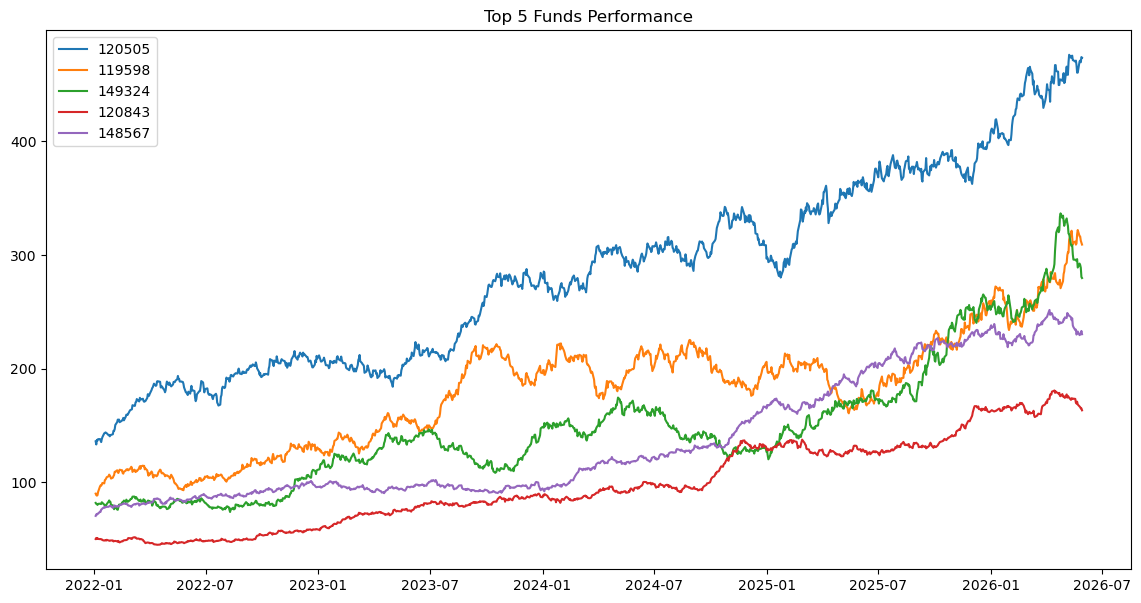

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(
figsize=(14,7)
)

for code in top5:

    temp = nav[
        nav["amfi_code"]==code
]

    plt.plot(temp["date"],temp["nav"],label=str(code)

)

plt.legend()

plt.title(
"Top 5 Funds Performance"
)

plt.show()

In [ ]:
plt.savefig(
"../reports/benchmark_comparison.png",bbox_inches="tight"
)

print("saved")

saved


<Figure size 640x480 with 0 Axes>